# Isolator / reflection testing via the ZABDC20-322H-S+ bidirectional coupler

**Coupler port map** (Mini-Circuits ZABDC20-322H-S+ datasheet):
- Port 1 = INPUT
- Port 4 = OUTPUT
- Port 2 = COUPLED (forward) -- samples the input->output traveling wave
- Port 3 = COUPLED (reverse) -- samples the output->input (reflected) traveling wave

Directivity spec across 2-3 GHz: 13-30 dB depending on frequency (better at the high end of the band). Whichever coupled port isn't being actively measured MUST be terminated in 50 ohm, or the coupler's effective directivity collapses.

**Important lesson learned the hard way**: before trusting any reflected-power reading, sanity-check that the analyzer is actually connected and the reading tracks the generator. On this E4403B, a disconnected/floating input reads a flat, power-independent, RF-on/RF-off-independent level around -45 to -48 dBm across 2-3 GHz -- easy to mistake for a real (if unexciting) signal. If a reading doesn't move when you sweep the generator's power over a wide range (e.g. -25 to -50 dBm) or when you turn RF off entirely, the cable isn't actually carrying signal. Always run the quick power/RF-off check below on a new physical setup before collecting a real sweep.

All previous data collected during the initial investigation of this setup turned out to be from a disconnected analyzer input and has been discarded. This notebook starts clean.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from hp8673h import HP8673H
from e4403b import E4403B
from frequency_sweep import frequency_sweep

START_HZ = 2.0e9
STOP_HZ = 3.0e9
STEP_HZ = 1e6
POWER_DBM = -25   # keep low -- especially important for no-load/full-reflection configurations

## Connection sanity check

Run this FIRST on any new physical setup, before collecting a real sweep. Fixes the generator frequency, steps its power over a wide range, and reads the analyzer. A real connection should show the reading track the power changes (until it drops into the noise floor at very low power) and drop further when RF is turned off. A flat, unchanging reading at every power level (including RF off) means the analyzer isn't actually seeing the generator's signal.

In [ ]:
FREQ_HZ = 2.5e9

gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)  # match the span used by the real sweeps below
sa.write("TRAC1:MODE WRITE")
sa.write("AVER:STATE OFF")
sa.write("INIT:CONT OFF")
sa.write("CALC:MARK1:MODE POS")

gen.preset()
gen.set_frequency_hz(FREQ_HZ)
gen.rf_on()

for power_dbm in [-25, -30, -35, -40, -45, -50]:
    gen.set_power_dbm(power_dbm)
    sa.write("INIT:IMM")
    sa.query("*OPC?")
    sa.write(f"CALC:MARK1:X {FREQ_HZ}")
    reading = float(sa.query("CALC:MARK1:Y?"))
    print(f"source {power_dbm:4d} dBm -> reads {reading:.2f} dBm")

gen.rf_off()
sa.write("INIT:IMM")
sa.query("*OPC?")
sa.write(f"CALC:MARK1:X {FREQ_HZ}")
reading_rf_off = float(sa.query("CALC:MARK1:Y?"))
print(f"RF OFF          -> reads {reading_rf_off:.2f} dBm")

gen.close()
sa.close()

## Reflected power sweep

Analyzer on the coupler's REVERSE port (port 3). Run once per physical configuration (open/no load, terminated, with isolator, etc.) -- change `RUN_LABEL` and the physical setup, then re-run this cell and the next.

In [1]:
RUN_LABEL = "no_isolator_open"

gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")
sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)

freqs_hz, power_dbm = frequency_sweep(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=STEP_HZ,
    power_dbm=POWER_DBM,
)

gen.close()
sa.close()

np.savetxt(
    f"data/reflected_{RUN_LABEL}_2-3GHz_1MHz.csv",
    np.column_stack((freqs_hz, power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)
print(f"{len(freqs_hz)} points collected, median {np.median(power_dbm):.1f} dBm")

1001 points collected, median -23.5 dBm


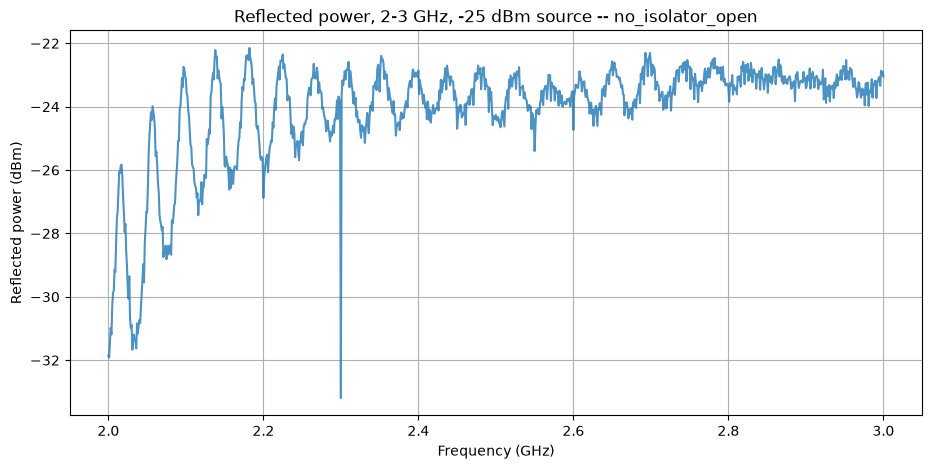

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(freqs_hz / 1e9, power_dbm, alpha=0.8)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title(f"Reflected power, 2-3 GHz, {POWER_DBM} dBm source -- {RUN_LABEL}")
ax.grid(True)
plt.show()

## Compare saved runs

Loads whatever `data/reflected_*.csv` files exist and overlays them -- doesn't require re-running the sweeps above.

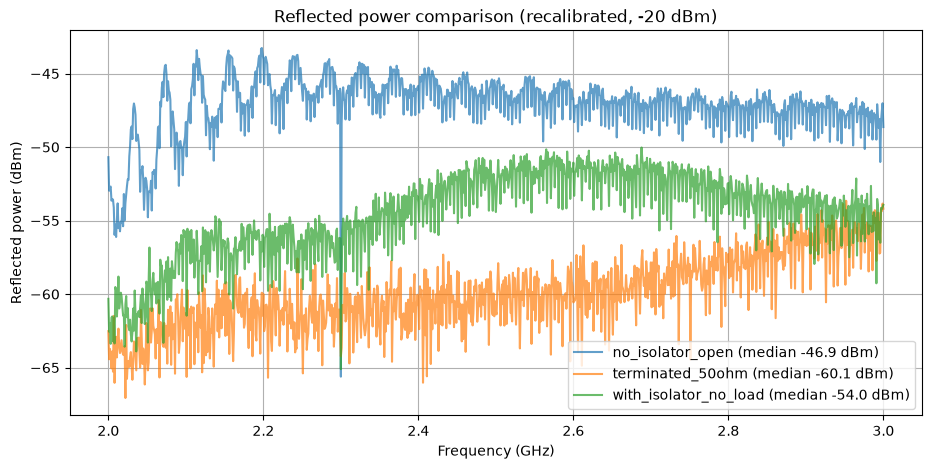

no_isolator_open: median -46.85 dBm
terminated_50ohm: median -60.08 dBm
with_isolator_no_load: median -54.02 dBm
isolator effect (no_isolator_open - with_isolator_no_load): 7.17 dB
coupler directivity floor (no_isolator_open - terminated_50ohm): 13.23 dB
isolator vs terminated floor (with_isolator_no_load - terminated_50ohm): 6.06 dB


In [11]:
import glob

fig, ax = plt.subplots(figsize=(11, 5))
runs = {}
for path in sorted(glob.glob("data/reflected_*.csv")):
    d = np.loadtxt(path, delimiter=",", skiprows=1)
    label = path.split("reflected_")[1].rsplit("_2-3GHz", 1)[0]
    runs[label] = d[:, 1]
    ax.plot(d[:, 0] / 1e9, d[:, 1], label=f"{label} (median {np.median(d[:, 1]):.1f} dBm)", alpha=0.7)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("Reflected power comparison")
ax.legend()
ax.grid(True)
plt.show()

for label, p in runs.items():
    print(f"{label}: median {np.median(p):.2f} dBm")

if "with_isolator_no_load" in runs and "no_isolator_open" in runs:
    diff = np.median(runs["no_isolator_open"]) - np.median(runs["with_isolator_no_load"])
    print(f"isolator effect (no_isolator_open - with_isolator_no_load): {diff:.2f} dB")
if "no_isolator_open" in runs and "terminated_50ohm" in runs:
    floor = np.median(runs["no_isolator_open"]) - np.median(runs["terminated_50ohm"])
    print(f"coupler directivity floor (no_isolator_open - terminated_50ohm): {floor:.2f} dB")
if "with_isolator_no_load" in runs and "terminated_50ohm" in runs:
    gap = np.median(runs["with_isolator_no_load"]) - np.median(runs["terminated_50ohm"])
    print(f"isolator vs terminated floor (with_isolator_no_load - terminated_50ohm): {gap:.2f} dB")